# IC3392 SIII9068 free-vs-tied fit inspection: previous selected bins

This notebook checks the `v3tk_v7.6.8_VELSCALE40_onlySIII9068` rerun in the 10 bins that were selected in the earlier full-line OIII failure notebook. Correction to the run label: this fit does not only fit SIII9068. The active gas lines are `HA6562`, `NII6583`, and `SIII9068`, all with free kinematics. The comparison fit is `v3tk_v7.6.8_VELSCALE40_use_SIII9068`, where OIII is also fitted and `SIII9068` is tied to that kinematic component.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import InlineBackend, set_matplotlib_formats
from astropy.io import fits

set_matplotlib_formats('png')
InlineBackend.instance().print_figure_kwargs = {'bbox_inches': None}

pd.set_option('display.max_columns', 220)
pd.set_option('display.max_rows', 260)
pd.set_option('display.max_colwidth', 180)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 160,
    'axes.grid': False,
})

root = Path.cwd()
GALAXY = 'IC3392'
REDSHIFT = 0.005566
SIII_LINE = 'SIII9068'
SIII_LABEL = '[S III] 9068'
SIII_REST_A = 9068.60
SIII_OBS_A = SIII_REST_A * (1.0 + REDSHIFT)
WAVE_HALF_WIDTH = 45.0
LINE_HALF_WIDTH = 14.0
C_KMS = 299792.458

RUNS = {
    'reference_7000_samebin': {
        'label': '7.6.8 7000/53 same-bin reference',
        'short_label': '7000 same-bin',
        'gas_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'line_cube_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_line_cube.fits',
        'color': '#1f77b4',
    },
    'free_siii9068': {
        'label': '7.6.8 9100/40 HA+NII+SIII9068 free',
        'short_label': 'HA/NII/SIII9068 free',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40_onlySIII9068' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'gas_bestfit_path': root / 'v3tk_v7.6.8_VELSCALE40_onlySIII9068' / GALAXY / f'{GALAXY}_gas_bestfit_bin.fits',
        'config_path': root / 'v3tk_v7.6.8_VELSCALE40_onlySIII9068' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_onlySIII9068_setonix.yaml',
        'emission_config_path': root / 'emissionLines_ppxf_onlySIII9068.config',
        'color': '#d62728',
    },
    'tied_siii9068': {
        'label': '7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied',
        'short_label': 'OIII+SIII9068 tied',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40_use_SIII9068' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'gas_bestfit_path': root / 'v3tk_v7.6.8_VELSCALE40_use_SIII9068' / GALAXY / f'{GALAXY}_gas_bestfit_bin.fits',
        'config_path': root / 'v3tk_v7.6.8_VELSCALE40_use_SIII9068' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_use_SIII9068_setonix.yaml',
        'emission_config_path': root / 'emissionLines_ppxf_use_SIII9068.config',
        'color': '#2ca02c',
    },
}
REF_RUN = 'reference_7000_samebin'
FREE_RUN = 'free_siii9068'
TIED_RUN = 'tied_siii9068'
FIT_RUNS = [FREE_RUN, TIED_RUN]

PREVIOUS_FULL_LINE_SELECTED_BINS = [
    ('large sigma ratio', 908),
    ('large sigma ratio', 3277),
    ('large sigma ratio', 2369),
    ('large sigma ratio', 347),
    ('large sigma ratio', 2358),
    ('large sigma ratio', 2310),
    ('large velocity difference', 2254),
    ('large velocity difference', 381),
    ('large velocity difference', 2349),
    ('large velocity difference', 3354),
]
SELECTED_BIN_IDS = [bin_id for _, bin_id in PREVIOUS_FULL_LINE_SELECTED_BINS]
PREVIOUS_REASON_BY_BIN = {bin_id: reason for reason, bin_id in PREVIOUS_FULL_LINE_SELECTED_BINS}
print('SIII9068 observed-frame center:', f'{SIII_OBS_A:.3f} Angstrom')
print('Selected previous full-line bins:', SELECTED_BIN_IDS)


SIII9068 observed-frame center: 9119.076 Angstrom
Selected previous full-line bins: [908, 3277, 2369, 347, 2358, 2310, 2254, 381, 2349, 3354]


## Verify Run Products And Line Lists

This confirms the corrected premise. In `onlySIII9068`, `HA6562`, `NII6583`, and `SIII9068` are active and free. In `use_SIII9068`, OIII is fitted and `SIII9068` is tied to that kinematic group. The reference GAS map is used only for the same-bin `BIN_ID` mask tied to the line cube.


In [2]:
def parse_emission_config(path):
    rows = []
    for lineno, raw_line in enumerate(path.read_text().splitlines(), start=1):
        stripped = raw_line.strip()
        if not stripped:
            continue
        commented = stripped.startswith('#')
        content = stripped.lstrip('#').strip() if commented else stripped
        parts = content.split()
        if len(parts) < 5 or not parts[0].isdigit():
            continue
        rest_air_a = float(parts[2])
        rows.append({
            'lineno': lineno,
            'index': int(parts[0]),
            'name': parts[1],
            'rest_air_a': rest_air_a,
            'line_id': f'{parts[1].upper()}{int(rest_air_a)}',
            'action': parts[3],
            'mode': parts[4],
            'commented_out': commented,
            'active_fit': (not commented) and parts[3] == 'f',
        })
    return pd.DataFrame(rows)


def read_simple_yaml(path):
    import yaml
    with open(path, 'r') as handle:
        return yaml.safe_load(handle)


def cfg_value(config, dotted_key):
    value = config
    for key in dotted_key.split('.'):
        if not isinstance(value, dict) or key not in value:
            return np.nan
        value = value[key]
    return value

run_rows = []
for run_key, run in RUNS.items():
    for product_key in ['gas_path', 'line_cube_path', 'gas_bestfit_path', 'config_path', 'emission_config_path']:
        path = run.get(product_key)
        if path is None:
            continue
        run_rows.append({
            'run_key': run_key,
            'product': product_key,
            'path': str(path.relative_to(root)),
            'exists': path.exists(),
            'size_MB': path.stat().st_size / 1024**2 if path.exists() else np.nan,
        })
run_product_table = pd.DataFrame(run_rows)
display(run_product_table)
assert run_product_table['exists'].all(), 'Missing one or more required input products.'

config_rows = []
active_line_tables = {}
for run_key in FIT_RUNS:
    run = RUNS[run_key]
    config = read_simple_yaml(run['config_path'])
    config_rows.append({
        'run_key': run_key,
        'run_label': run['label'],
        'READ_DATA.LMIN_TOT': cfg_value(config, 'READ_DATA.LMIN_TOT'),
        'READ_DATA.LMAX_TOT': cfg_value(config, 'READ_DATA.LMAX_TOT'),
        'PREPARE_SPECTRA.VELSCALE': cfg_value(config, 'PREPARE_SPECTRA.VELSCALE'),
        'GAS.LMIN': cfg_value(config, 'GAS.LMIN'),
        'GAS.LMAX': cfg_value(config, 'GAS.LMAX'),
        'GAS.EMI_FILE': cfg_value(config, 'GAS.EMI_FILE'),
        'GAS.MOM': cfg_value(config, 'GAS.MOM'),
        'GAS.FIXED': cfg_value(config, 'GAS.FIXED'),
    })
    emission_table = parse_emission_config(run['emission_config_path'])
    active_line_tables[run_key] = emission_table[emission_table['active_fit']].copy()
config_summary = pd.DataFrame(config_rows)
display(config_summary)

active_line_rows = []
for run_key, table in active_line_tables.items():
    for _, row in table.iterrows():
        active_line_rows.append({
            'run_key': run_key,
            'run_label': RUNS[run_key]['label'],
            'lineno': row['lineno'],
            'line_id': row['line_id'],
            'name': row['name'],
            'rest_air_a': row['rest_air_a'],
            'action': row['action'],
            'mode': row['mode'],
        })
active_line_summary = pd.DataFrame(active_line_rows)
display(active_line_summary)

free_active = active_line_tables[FREE_RUN][['line_id', 'mode']].reset_index(drop=True)
expected_free = pd.DataFrame({'line_id': ['HA6562', 'NII6583', SIII_LINE], 'mode': ['f', 'f', 'f']})
assert free_active.equals(expected_free), 'Expected only HA6562, NII6583, and SIII9068 active/free in the corrected free run.'

tied_siii_mode = active_line_tables[TIED_RUN].set_index('line_id').loc[SIII_LINE, 'mode']
assert tied_siii_mode == 'k17', 'Expected SIII9068 to be tied with mode k17 in use_SIII9068.'


,run_key,product,path,exists,size_MB
0,reference_7000_samebin,gas_path,v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_gas_bin_maps.fits,True,152.251282
1,reference_7000_samebin,line_cube_path,v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_line_cube.fits,True,2525.616760
2,free_siii9068,gas_path,v3tk_v7.6.8_VELSCALE40_onlySIII9068/IC3392/IC3392_gas_bin_maps.fits,True,36.600952
3,free_siii9068,gas_bestfit_path,v3tk_v7.6.8_VELSCALE40_onlySIII9068/IC3392/IC3392_gas_bestfit_bin.fits,True,294.952698
4,free_siii9068,config_path,v3tk_v7.6.8_VELSCALE40_onlySIII9068/IC3392/IC3392_MAUVE_MasterConfig_v7.6.8_VELSCALE40_onlySIII9068_setonix.yaml,True,0.002275
5,free_siii9068,emission_config_path,emissionLines_ppxf_onlySIII9068.config,True,0.003365
6,tied_siii9068,gas_path,v3tk_v7.6.8_VELSCALE40_use_SIII9068/IC3392/IC3392_gas_bin_maps.fits,True,172.746277
7,tied_siii9068,gas_bestfit_path,v3tk_v7.6.8_VELSCALE40_use_SIII9068/IC3392/IC3392_gas_bestfit_bin.fits,True,294.952698
8,tied_siii9068,config_path,v3tk_v7.6.8_VELSCALE40_use_SIII9068/IC3392/IC3392_MAUVE_MasterConfig_v7.6.8_VELSCALE40_use_SIII9068_setonix.yaml,True,0.002275
9,tied_siii9068,emission_config_path,emissionLines_ppxf_use_SIII9068.config,True,0.003354


,run_key,run_label,READ_DATA.LMIN_TOT,READ_DATA.LMAX_TOT,PREPARE_SPECTRA.VELSCALE,GAS.LMIN,GAS.LMAX,GAS.EMI_FILE,GAS.MOM,GAS.FIXED
0,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,4800,9100,40,4800,9100,emissionLines_ppxf_onlySIII9068.config,2,True
1,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",4800,9100,40,4800,9100,emissionLines_ppxf_use_SIII9068.config,2,True


,run_key,run_label,lineno,line_id,name,rest_air_a,action,mode
0,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,35,HA6562,Ha,6562.79,f,f
1,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,36,NII6583,NII,6583.45,f,f
2,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,47,SIII9068,SIII,9068.60,f,f
3,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",24,HB4861,Hb,4861.35,f,k26
4,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",25,OIII4958,OIII,4958.91,f,a17
5,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",26,OIII5006,OIII,5006.84,f,f
6,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",29,NII5754,NII,5754.59,f,k27
7,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",31,OI6300,OI,6300.30,f,k27
8,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",33,OI6363,OI,6363.78,f,a22
9,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",34,NII6548,NII,6548.05,f,a27


## Verify FITS Extensions And Binning

The line cube comes from the 7000 same-bin folder, so both comparison-run `BIN_ID` maps must match before summing spectra by bin. This section also verifies that both comparison runs expose SIII9068 `FLUX`, `VEL`, and `SIGMA` maps for morphology and pairwise checks.


In [3]:
def fits_extnames(path):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        return [hdu.name for hdu in hdul]


def read_map(path, extname):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        arr = np.array(hdul[extname].data, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    return arr

ref_bins = read_map(RUNS[REF_RUN]['gas_path'], 'BIN_ID')
baseline_bins = ref_bins
fit_extnames_by_run = {run_key: set(fits_extnames(RUNS[run_key]['gas_path'])) for run_key in FIT_RUNS}
required_siii_exts = ['BIN_ID'] + [f'{SIII_LINE}_{suffix}' for suffix in ['FLUX', 'FLUX_ERR', 'VEL', 'VEL_ERR', 'SIGMA', 'SIGMA_ERR', 'SIGMA_CORR']]
extension_rows = []
binning_rows = []
for run_key in FIT_RUNS:
    extnames = fit_extnames_by_run[run_key]
    for ext in required_siii_exts:
        extension_rows.append({
            'run_key': run_key,
            'run_label': RUNS[run_key]['label'],
            'required_extension': ext,
            'available': ext in extnames,
        })
    fit_bins = read_map(RUNS[run_key]['gas_path'], 'BIN_ID')
    same_shape = ref_bins.shape == fit_bins.shape
    exact_equal = bool(same_shape and np.array_equal(ref_bins, fit_bins, equal_nan=True))
    finite_both = np.isfinite(ref_bins) & np.isfinite(fit_bins) if same_shape else np.zeros(ref_bins.shape, dtype=bool)
    binning_rows.append({
        'run_key': run_key,
        'run_label': RUNS[run_key]['label'],
        'same_shape': same_shape,
        'exact_equal_including_nan': exact_equal,
        'finite_pixels_in_both': int(finite_both.sum()) if same_shape else np.nan,
        'n_finite_mismatches': int(np.count_nonzero(finite_both & (ref_bins != fit_bins))) if same_shape else np.nan,
    })
extension_check = pd.DataFrame(extension_rows)
binning_check = pd.DataFrame(binning_rows)
display(extension_check)
display(binning_check)
assert extension_check['available'].all(), 'Missing SIII9068 map extensions in one of the comparison runs.'
assert binning_check['exact_equal_including_nan'].all(), 'One or more comparison BIN_ID maps do not match the reference line cube.'

available_flux_lines = []
for run_key, extnames in fit_extnames_by_run.items():
    for line_id in sorted(ext[:-5] for ext in extnames if ext.endswith('_FLUX')):
        available_flux_lines.append({'run_key': run_key, 'line_id_with_flux_map': line_id})
display(pd.DataFrame(available_flux_lines))


,run_key,run_label,required_extension,available
0,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,BIN_ID,True
1,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,SIII9068_FLUX,True
2,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,SIII9068_FLUX_ERR,True
3,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,SIII9068_VEL,True
4,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,SIII9068_VEL_ERR,True
5,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,SIII9068_SIGMA,True
6,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,SIII9068_SIGMA_ERR,True
7,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,SIII9068_SIGMA_CORR,True
8,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",BIN_ID,True
9,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",SIII9068_FLUX,True


,run_key,run_label,same_shape,exact_equal_including_nan,finite_pixels_in_both,n_finite_mismatches
0,free_siii9068,7.6.8 9100/40 HA+NII+SIII9068 free,True,True,94543,0
1,tied_siii9068,"7.6.8 9100/40 use_SIII9068, OIII fitted and SIII9068 tied",True,True,94543,0


,run_key,line_id_with_flux_map
0,free_siii9068,HA6562
1,free_siii9068,NII6583
2,free_siii9068,SIII9068
3,tied_siii9068,HA6562
4,tied_siii9068,HB4861
5,tied_siii9068,NII5754
6,tied_siii9068,NII6548
7,tied_siii9068,NII6583
8,tied_siii9068,OI6300
9,tied_siii9068,OI6363


## Wavelength Coverage

This check is critical because `SIII9068` lands near the red end of the observed cube. Both the observed line cube and stored `GAS_BESTFIT` should cover the SIII9068 window used for visual inspection.


In [4]:
def wavelength_from_header(header, n_wave):
    crpix = header.get('CRPIX3', 1.0)
    crval = header.get('CRVAL3')
    cdelt = header.get('CDELT3', header.get('CD3_3'))
    if crval is None or cdelt is None:
        raise ValueError('Cannot construct wavelength vector from cube header.')
    return crval + (np.arange(n_wave) + 1 - crpix) * cdelt

with fits.open(RUNS[REF_RUN]['line_cube_path'], memmap=True, ignore_missing_end=True) as hdul:
    line_cube_shape = hdul[0].data.shape
    line_cube_wave = wavelength_from_header(hdul[0].header, line_cube_shape[0])

coverage_rows = []
for source, wave in [('line_cube', line_cube_wave)]:
    for half_width in [LINE_HALF_WIDTH, 20.0, WAVE_HALF_WIDTH, 80.0]:
        mask = (wave >= SIII_OBS_A - half_width) & (wave <= SIII_OBS_A + half_width)
        coverage_rows.append({
            'source': source,
            'wave_min_a': float(np.nanmin(wave)),
            'wave_max_a': float(np.nanmax(wave)),
            'n_wave_pixels_total': int(len(wave)),
            'window_half_width_a': half_width,
            'window_blue_a': SIII_OBS_A - half_width,
            'window_red_a': SIII_OBS_A + half_width,
            'n_pixels_in_window': int(np.count_nonzero(mask)),
            'covered_window_min_a': float(np.nanmin(wave[mask])) if np.any(mask) else np.nan,
            'covered_window_max_a': float(np.nanmax(wave[mask])) if np.any(mask) else np.nan,
        })

bestfit_wave_by_run = {}
n_bestfit_bins_by_run = {}
for run_key in FIT_RUNS:
    with fits.open(RUNS[run_key]['gas_bestfit_path'], memmap=True, ignore_missing_end=True) as hdul:
        wave = np.exp(np.asarray(hdul['LOGLAM'].data['LOGLAM'], dtype=float)) * (1.0 + REDSHIFT)
        bestfit_wave_by_run[run_key] = wave
        n_bestfit_bins_by_run[run_key] = len(hdul['GAS_BESTFIT'].data['GAS_BESTFIT'])
    for half_width in [LINE_HALF_WIDTH, 20.0, WAVE_HALF_WIDTH, 80.0]:
        mask = (wave >= SIII_OBS_A - half_width) & (wave <= SIII_OBS_A + half_width)
        coverage_rows.append({
            'source': f'GAS_BESTFIT {RUNS[run_key]["short_label"]}',
            'wave_min_a': float(np.nanmin(wave)),
            'wave_max_a': float(np.nanmax(wave)),
            'n_wave_pixels_total': int(len(wave)),
            'window_half_width_a': half_width,
            'window_blue_a': SIII_OBS_A - half_width,
            'window_red_a': SIII_OBS_A + half_width,
            'n_pixels_in_window': int(np.count_nonzero(mask)),
            'covered_window_min_a': float(np.nanmin(wave[mask])) if np.any(mask) else np.nan,
            'covered_window_max_a': float(np.nanmax(wave[mask])) if np.any(mask) else np.nan,
        })
coverage_table = pd.DataFrame(coverage_rows)
display(coverage_table)
print('GAS_BESTFIT bins available:', n_bestfit_bins_by_run)


,source,wave_min_a,wave_max_a,n_wave_pixels_total,window_half_width_a,window_blue_a,window_red_a,n_pixels_in_window,covered_window_min_a,covered_window_max_a
0,line_cube,4827.500000,9150.000000,3459,14.0,9105.075828,9133.075828,22,9106.250000,9132.500000
1,line_cube,4827.500000,9150.000000,3459,20.0,9099.075828,9139.075828,32,9100.000000,9138.750000
2,line_cube,4827.500000,9150.000000,3459,45.0,9074.075828,9164.075828,61,9075.000000,9150.000000
3,line_cube,4827.500000,9150.000000,3459,80.0,9039.075828,9199.075828,89,9040.000000,9150.000000
4,GAS_BESTFIT HA/NII/SIII9068 free,4827.197025,9148.972984,4793,14.0,9105.075828,9133.075828,23,9105.132886,9131.899030
5,GAS_BESTFIT HA/NII/SIII9068 free,4827.197025,9148.972984,4793,20.0,9099.075828,9139.075828,32,9100.274749,9137.993210
6,GAS_BESTFIT HA/NII/SIII9068 free,4827.197025,9148.972984,4793,45.0,9074.075828,9164.075828,62,9074.812029,9148.972984
7,GAS_BESTFIT HA/NII/SIII9068 free,4827.197025,9148.972984,4793,80.0,9039.075828,9199.075828,91,9039.766310,9148.972984
8,GAS_BESTFIT OIII+SIII9068 tied,4827.197025,9148.972984,4793,14.0,9105.075828,9133.075828,23,9105.132886,9131.899030
9,GAS_BESTFIT OIII+SIII9068 tied,4827.197025,9148.972984,4793,20.0,9099.075828,9139.075828,32,9100.274749,9137.993210


GAS_BESTFIT bins available: {'free_siii9068': 4032, 'tied_siii9068': 4032}


## SIII9068 Map Values For The 10 Bins

This table reports the fitted SIII9068 map quantities in the fixed previous selected bins for both comparison runs. It is useful context for judging whether the plotted `GAS_BESTFIT` spectrum is a high-significance or low-significance fit, and whether freeing SIII9068 changed the fitted kinematics.


In [5]:
def median_map_value_for_bin(arr, bin_id):
    values = arr[baseline_bins == int(bin_id)]
    values = values[np.isfinite(values)]
    return float(np.nanmedian(values)) if values.size else np.nan

rows, cols = np.indices(baseline_bins.shape)
siii_maps_by_run = {
    run_key: {
        suffix.lower(): read_map(RUNS[run_key]['gas_path'], f'{SIII_LINE}_{suffix}')
        for suffix in ['FLUX', 'FLUX_ERR', 'VEL', 'VEL_ERR', 'SIGMA', 'SIGMA_ERR', 'SIGMA_CORR']
    }
    for run_key in FIT_RUNS
}
selected_rows = []
for order, (reason, bin_id) in enumerate(PREVIOUS_FULL_LINE_SELECTED_BINS, start=1):
    bin_mask = baseline_bins == int(bin_id)
    base_row = {
        'order': order,
        'selection_reason': reason,
        'bin_id': int(bin_id),
        'n_spaxels': int(np.count_nonzero(bin_mask)),
        'row': float(np.nanmedian(rows[bin_mask])) if np.any(bin_mask) else np.nan,
        'col': float(np.nanmedian(cols[bin_mask])) if np.any(bin_mask) else np.nan,
    }
    for run_key in FIT_RUNS:
        maps = siii_maps_by_run[run_key]
        flux = median_map_value_for_bin(maps['flux'], bin_id)
        flux_err = median_map_value_for_bin(maps['flux_err'], bin_id)
        prefix = 'free' if run_key == FREE_RUN else 'tied'
        base_row.update({
            f'{prefix}_flux': flux,
            f'{prefix}_flux_err': flux_err,
            f'{prefix}_fluxerr': flux / flux_err if np.isfinite(flux) and np.isfinite(flux_err) and flux_err > 0 else np.nan,
            f'{prefix}_vel': median_map_value_for_bin(maps['vel'], bin_id),
            f'{prefix}_vel_err': median_map_value_for_bin(maps['vel_err'], bin_id),
            f'{prefix}_sigma': median_map_value_for_bin(maps['sigma'], bin_id),
            f'{prefix}_sigma_err': median_map_value_for_bin(maps['sigma_err'], bin_id),
            f'{prefix}_sigma_corr': median_map_value_for_bin(maps['sigma_corr'], bin_id),
        })
    base_row['free_minus_tied_vel'] = base_row['free_vel'] - base_row['tied_vel']
    base_row['free_minus_tied_sigma'] = base_row['free_sigma'] - base_row['tied_sigma']
    base_row['free_over_tied_flux'] = base_row['free_flux'] / base_row['tied_flux'] if np.isfinite(base_row['free_flux']) and np.isfinite(base_row['tied_flux']) and base_row['tied_flux'] != 0 else np.nan
    selected_rows.append(base_row)
selected_bin_table = pd.DataFrame(selected_rows)
display(selected_bin_table)


,order,selection_reason,bin_id,n_spaxels,row,col,free_flux,free_flux_err,free_fluxerr,free_vel,free_vel_err,free_sigma,free_sigma_err,free_sigma_corr,tied_flux,tied_flux_err,tied_fluxerr,tied_vel,tied_vel_err,tied_sigma,tied_sigma_err,tied_sigma_corr,free_minus_tied_vel,free_minus_tied_sigma,free_over_tied_flux
0,1,large sigma ratio,908,451,87.0,187.0,0.000000,0.393676,0.000000,-4.238047,3.577490e-14,61.167330,1.861406e-14,35.234107,6.332647,0.642497,9.856304,4.876831,8.853070,157.382519,8.302589,35.234107,-9.114879,-96.215189,0.000000
1,2,large sigma ratio,3277,8,200.0,292.0,125.729911,9.641304,13.040758,-54.574442,1.931921e+01,182.301965,2.182469e+01,35.234107,107.295381,8.563375,12.529567,-24.839101,8.386806,142.732438,9.267911,35.234107,-29.735340,39.569527,1.171811
2,3,large sigma ratio,2369,16,304.0,162.0,77.853138,3.012856,25.840316,128.073468,2.183167e+00,39.450821,4.806888e+00,35.234107,80.282744,3.078889,26.075233,123.745658,1.998237,41.524877,4.186508,35.234107,4.327810,-2.074056,0.969737
3,4,large sigma ratio,347,11,195.0,213.0,166.878707,4.769348,34.989839,28.505418,2.270362e+00,58.065580,2.970411e+00,35.234107,176.737186,4.980358,35.486846,28.289704,2.154835,64.273680,2.810122,35.234107,0.215714,-6.208100,0.944220
4,5,large sigma ratio,2358,10,297.5,192.0,62.380245,3.795193,16.436646,123.526276,3.883247e+00,41.236762,6.387263e+00,35.234107,68.833084,4.123682,16.692141,121.228451,3.224737,50.072125,5.208188,35.234107,2.297826,-8.835363,0.906254
5,6,large sigma ratio,2310,4,229.5,256.5,183.348708,14.270400,12.848183,-30.306870,1.793653e+01,175.377482,2.003045e+01,35.234107,127.891179,11.554848,11.068184,-8.862614,7.109244,115.902315,8.074824,35.234107,-21.444256,59.475167,1.433631
6,7,large velocity difference,2254,9,296.0,190.0,74.221609,4.178413,17.763109,121.727692,3.704753e+00,46.381898,5.913259e+00,35.234107,85.259878,4.708390,18.108073,119.135846,3.533603,60.819467,4.888591,35.234107,2.591847,-14.437568,0.870534
7,8,large velocity difference,381,11,193.0,211.0,138.888454,4.986618,27.852232,29.315949,3.208252e+00,64.567384,3.964231e+00,35.234107,168.020025,5.854409,28.699741,44.760977,3.066139,92.986773,3.678969,35.234107,-15.445027,-28.419389,0.826618
8,9,large velocity difference,2349,10,298.5,188.0,92.697689,4.634305,20.002500,135.703779,3.479582e+00,48.441827,5.077646e+00,35.234107,96.707007,4.789837,20.190042,126.179555,2.863478,52.863143,4.363699,35.234107,9.524224,-4.421316,0.958542
9,10,large velocity difference,3354,9,164.0,284.0,55.693233,5.216786,10.675775,-157.804037,8.986672e+00,63.063830,1.103871e+01,35.234107,33.674949,5.708822,5.898756,-65.644479,5.377382,80.052865,7.793549,35.234107,-92.159558,-16.989035,1.653848


## SIII9068 Flux, Velocity, And Sigma Maps

This 3-by-2 map view compares the two SIII9068 runs directly: free HA/NII/SIII9068 on the left and tied OIII+SIII9068 on the right. The same color scale is used within each row so morphology changes are visually comparable.


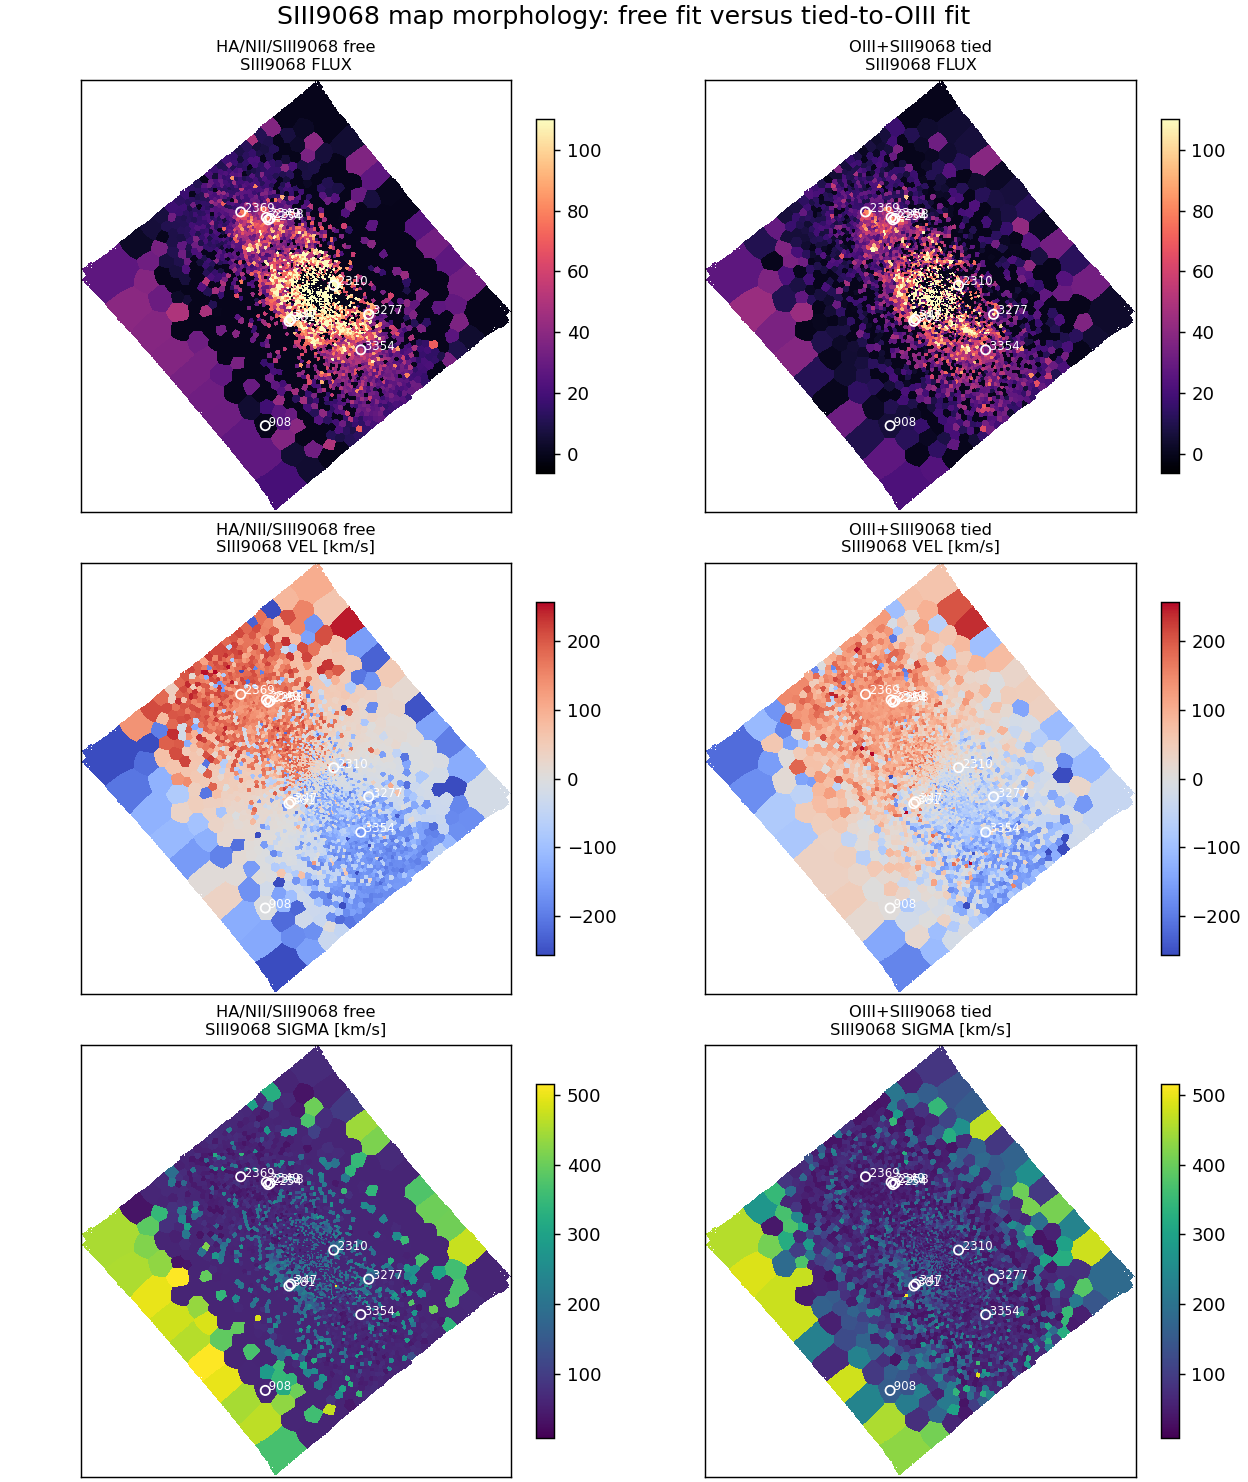

In [6]:
def robust_limits(values, p=(2, 98), pad_fraction=0.06, fallback=(-1, 1)):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return fallback
    lo, hi = np.nanpercentile(values, p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return fallback
    pad = (hi - lo) * pad_fraction
    return float(lo - pad), float(hi + pad)


map_specs = [
    {'suffix': 'flux', 'label': 'SIII9068 FLUX', 'cmap': 'magma', 'transform': lambda x: x},
    {'suffix': 'vel', 'label': 'SIII9068 VEL [km/s]', 'cmap': 'coolwarm', 'transform': lambda x: x},
    {'suffix': 'sigma', 'label': 'SIII9068 SIGMA [km/s]', 'cmap': 'viridis', 'transform': lambda x: x},
]
fig, axes = plt.subplots(3, 2, figsize=(9.6, 11.4), constrained_layout=True)
fig.suptitle('SIII9068 map morphology: free fit versus tied-to-OIII fit', fontsize=14)
selected_xy = selected_bin_table[['col', 'row', 'bin_id']].copy()

for row_idx, spec in enumerate(map_specs):
    arrays = [spec['transform'](siii_maps_by_run[run_key][spec['suffix']]) for run_key in FIT_RUNS]
    finite_chunks = [arr[np.isfinite(arr)] for arr in arrays if np.isfinite(arr).any()]
    finite_values = np.concatenate(finite_chunks) if finite_chunks else np.array([])
    if spec['suffix'] == 'vel':
        vmax = np.nanpercentile(np.abs(finite_values), 98) if finite_values.size else 1.0
        vmax = float(vmax) if np.isfinite(vmax) and vmax > 0 else 1.0
        vmin, vmax = -vmax, vmax
    else:
        vmin, vmax = robust_limits(finite_values, p=(2, 98), fallback=(0, 1))
    for col_idx, run_key in enumerate(FIT_RUNS):
        ax = axes[row_idx, col_idx]
        arr = np.ma.masked_invalid(arrays[col_idx])
        im = ax.imshow(arr, origin='lower', cmap=spec['cmap'], vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.scatter(selected_xy['col'], selected_xy['row'], s=26, facecolors='none', edgecolors='white', linewidths=1.0)
        for _, point in selected_xy.iterrows():
            ax.text(point['col'], point['row'], f' {int(point["bin_id"])}', color='white', fontsize=6.5)
        ax.set_title(f'{RUNS[run_key]["short_label"]}\n{spec["label"]}', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, shrink=0.82)
plt.show()

## SIII9068 Pairwise And Residual Plots

These plots compare the two SIII9068 runs bin-by-bin. The gray cloud still shows the full same-bin population, but the plot limits are zoomed from the 10 previously selected bins. Residuals are `free - tied` for velocity, while flux and sigma use log-ratio residuals following the earlier OIII notebook convention.

,bin_id,tied_fluxerr,free_fluxerr,tied_vel,free_vel,free_minus_tied_vel,tied_sigma,free_sigma,free_minus_tied_sigma,free_over_tied_sigma
0,0,0.000000,9.408501,26.176855,-150.984444,-177.161299,57.608808,68.255904,10.647096,1.184817
1,1,7.479727,8.091035,-57.811898,-106.210112,-48.398215,190.547740,230.662074,40.114334,1.210521
2,2,9.351176,9.803167,-21.729377,-43.168253,-21.438876,164.426314,191.703178,27.276864,1.165891
3,3,7.824419,9.013369,-4.392683,-51.748237,-47.355554,158.553647,211.588314,53.034667,1.334490
4,4,7.687598,8.220029,17.821804,-36.543093,-54.364897,176.051396,192.429012,16.377616,1.093027


,bin_id,tied_fluxerr,free_fluxerr,log10_flux_ratio,free_minus_tied_vel,free_over_tied_sigma,log10_sigma_ratio
347,347,35.486846,34.989839,-0.024927,0.215714,0.903411,-0.044114
381,381,28.699741,27.852232,-0.082695,-15.445027,0.694372,-0.158408
908,908,9.856304,0.000000,NaN,-9.114879,0.388654,-0.410437
2254,2254,18.108073,17.763109,-0.060214,2.591847,0.762616,-0.117694
2310,2310,11.068184,12.848183,0.156437,-21.444256,1.513149,0.179882
2349,2349,20.190042,20.002500,-0.018389,9.524224,0.916363,-0.037932
2358,2358,16.692141,16.436646,-0.042750,2.297826,0.823547,-0.084311
2369,2369,26.075233,25.840316,-0.013346,4.327810,0.950053,-0.022252
3277,3277,12.529567,13.040758,0.068858,-29.735340,1.277229,0.106269
3354,3354,5.898756,10.675775,0.218495,-92.159558,0.787777,-0.103597


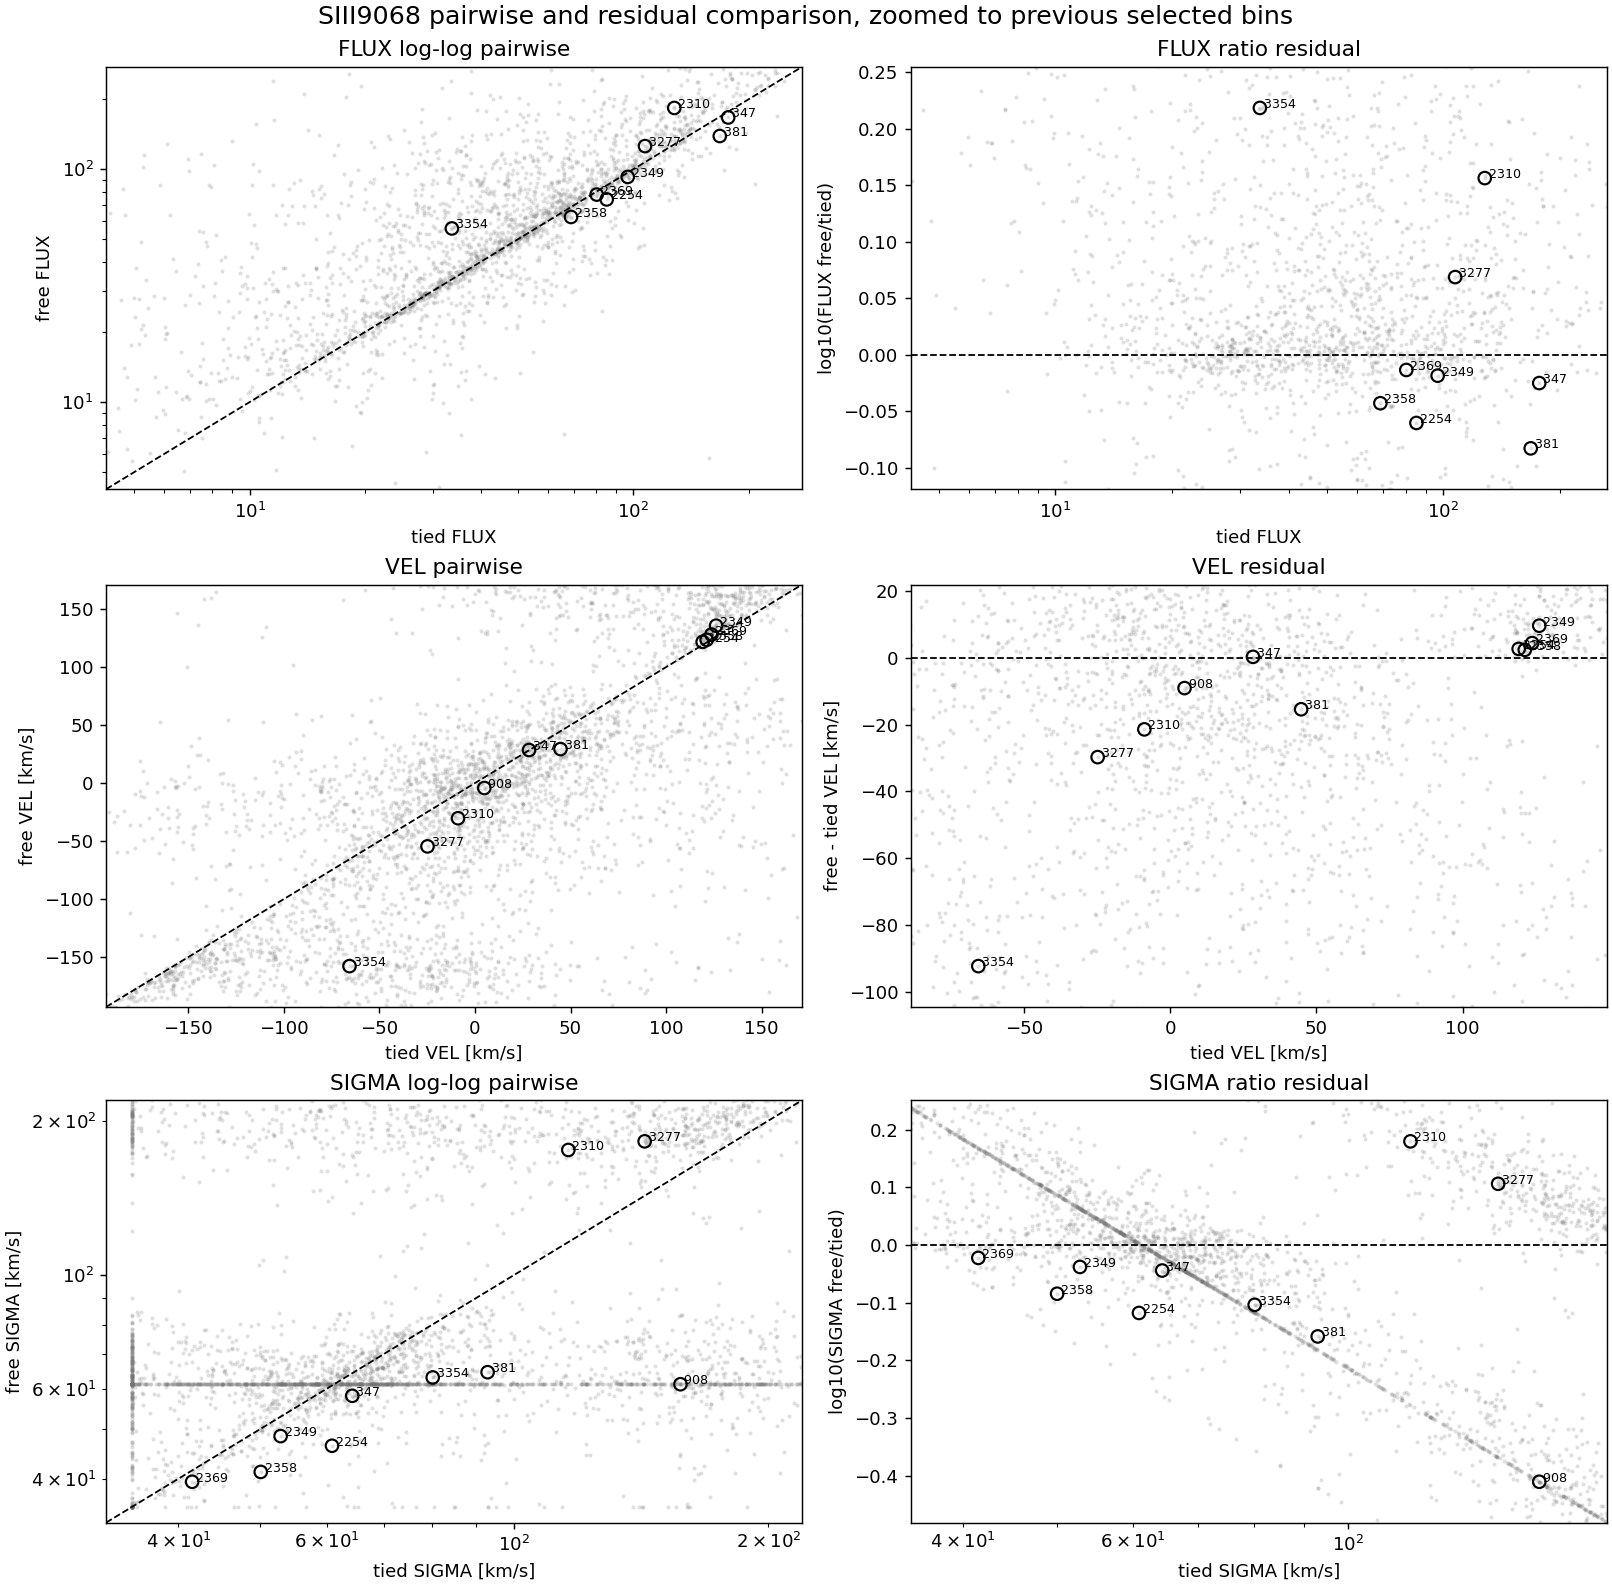

In [7]:
valid_pixels = np.isfinite(baseline_bins) & (baseline_bins >= 0)
pair_pixel_table = pd.DataFrame({
    'bin_id': baseline_bins[valid_pixels].astype(int),
})
for run_key, prefix in [(FREE_RUN, 'free'), (TIED_RUN, 'tied')]:
    maps = siii_maps_by_run[run_key]
    for suffix in ['flux', 'flux_err', 'vel', 'sigma']:
        pair_pixel_table[f'{prefix}_{suffix}'] = maps[suffix][valid_pixels]
pair_bin_table = pair_pixel_table.groupby('bin_id', as_index=False).median(numeric_only=True)
for prefix in ['free', 'tied']:
    pair_bin_table[f'{prefix}_fluxerr'] = pair_bin_table[f'{prefix}_flux'] / pair_bin_table[f'{prefix}_flux_err']
    pair_bin_table.loc[~np.isfinite(pair_bin_table[f'{prefix}_fluxerr']), f'{prefix}_fluxerr'] = np.nan
pair_bin_table['free_minus_tied_flux'] = pair_bin_table['free_flux'] - pair_bin_table['tied_flux']
pair_bin_table['free_minus_tied_vel'] = pair_bin_table['free_vel'] - pair_bin_table['tied_vel']
pair_bin_table['free_minus_tied_sigma'] = pair_bin_table['free_sigma'] - pair_bin_table['tied_sigma']

pair_bin_table['free_over_tied_flux'] = pair_bin_table['free_flux'] / pair_bin_table['tied_flux']
pair_bin_table.loc[~np.isfinite(pair_bin_table['free_over_tied_flux']) | (pair_bin_table['free_over_tied_flux'] <= 0), 'free_over_tied_flux'] = np.nan
pair_bin_table['log10_flux_ratio'] = np.log10(pair_bin_table['free_over_tied_flux'])

pair_bin_table['free_over_tied_sigma'] = pair_bin_table['free_sigma'] / pair_bin_table['tied_sigma']
pair_bin_table.loc[~np.isfinite(pair_bin_table['free_over_tied_sigma']) | (pair_bin_table['free_over_tied_sigma'] <= 0), 'free_over_tied_sigma'] = np.nan
pair_bin_table['log10_sigma_ratio'] = np.log10(pair_bin_table['free_over_tied_sigma'])

display(pair_bin_table[['bin_id', 'tied_fluxerr', 'free_fluxerr', 'tied_vel', 'free_vel', 'free_minus_tied_vel', 'tied_sigma', 'free_sigma', 'free_minus_tied_sigma', 'free_over_tied_sigma']].head())
display(pair_bin_table[pair_bin_table['bin_id'].isin(SELECTED_BIN_IDS)][['bin_id', 'tied_fluxerr', 'free_fluxerr', 'log10_flux_ratio', 'free_minus_tied_vel', 'free_over_tied_sigma', 'log10_sigma_ratio']])

plot_sample = pair_bin_table.copy()
if len(plot_sample) > 25000:
    plot_sample = plot_sample.sample(25000, random_state=12)
selected_pair = pair_bin_table[pair_bin_table['bin_id'].isin(SELECTED_BIN_IDS)].copy()


def finite_values(series, positive=False):
    values = np.asarray(series, dtype=float)
    keep = np.isfinite(values)
    if positive:
        keep &= values > 0
    return values[keep]


def selected_axis_limits(values, *, positive=False, log=False, include_zero=False, fallback=(-1, 1), pad_fraction=0.12):
    values = finite_values(values, positive=positive)
    if include_zero and not positive:
        values = np.concatenate([values, np.array([0.0])])
    if values.size == 0:
        return fallback
    if log:
        values = finite_values(values, positive=True)
        if values.size == 0:
            return fallback
        work = np.log10(values)
        fallback_work = np.log10(np.asarray(fallback, dtype=float))
    else:
        work = values
        fallback_work = np.asarray(fallback, dtype=float)
    lo, hi = np.nanmin(work), np.nanmax(work)
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = fallback_work
    if lo == hi:
        center = lo
        width = max(abs(center) * 0.08, 0.08 if not log else 0.04)
        lo, hi = center - width, center + width
    pad = (hi - lo) * pad_fraction
    lo, hi = lo - pad, hi + pad
    if log:
        return float(10**lo), float(10**hi)
    return float(lo), float(hi)


def selected_xy_limits(x_col, y_col, *, log=False, fallback=(-1, 1)):
    values = np.concatenate([
        finite_values(selected_pair[x_col], positive=log),
        finite_values(selected_pair[y_col], positive=log),
    ])
    return selected_axis_limits(values, positive=log, log=log, fallback=fallback)


def selected_residual_limits(x_col, resid_col, *, x_log=False, y_include_zero=True, x_fallback=(-1, 1), y_fallback=(-1, 1)):
    xlim = selected_axis_limits(selected_pair[x_col], positive=x_log, log=x_log, fallback=x_fallback)
    ylim = selected_axis_limits(selected_pair[resid_col], include_zero=y_include_zero, fallback=y_fallback)
    return xlim, ylim


quantity_specs = [
    {
        'name': 'flux',
        'x': 'tied_flux',
        'y': 'free_flux',
        'resid': 'log10_flux_ratio',
        'pair_label': 'FLUX',
        'pair_title': 'FLUX log-log pairwise',
        'resid_label': 'log10(FLUX free/tied)',
        'resid_title': 'FLUX ratio residual',
        'log_pair': True,
        'log_resid_x': True,
        'pair_fallback': (1e-3, 1),
        'resid_x_fallback': (1e-3, 1),
        'resid_y_fallback': (-0.5, 0.5),
    },
    {
        'name': 'vel',
        'x': 'tied_vel',
        'y': 'free_vel',
        'resid': 'free_minus_tied_vel',
        'pair_label': 'VEL [km/s]',
        'pair_title': 'VEL pairwise',
        'resid_label': 'free - tied VEL [km/s]',
        'resid_title': 'VEL residual',
        'log_pair': False,
        'log_resid_x': False,
        'pair_fallback': (-150, 150),
        'resid_x_fallback': (-150, 150),
        'resid_y_fallback': (-25, 25),
    },
    {
        'name': 'sigma',
        'x': 'tied_sigma',
        'y': 'free_sigma',
        'resid': 'log10_sigma_ratio',
        'pair_label': 'SIGMA [km/s]',
        'pair_title': 'SIGMA log-log pairwise',
        'resid_label': 'log10(SIGMA free/tied)',
        'resid_title': 'SIGMA ratio residual',
        'log_pair': True,
        'log_resid_x': True,
        'pair_fallback': (10, 400),
        'resid_x_fallback': (10, 400),
        'resid_y_fallback': (-0.3, 0.3),
    },
]

fig, axes = plt.subplots(3, 2, figsize=(12.4, 12.2), constrained_layout=True)
fig.suptitle('SIII9068 pairwise and residual comparison, zoomed to previous selected bins', fontsize=14)

for row_idx, spec in enumerate(quantity_specs):
    ax = axes[row_idx, 0]
    x = plot_sample[spec['x']]
    y = plot_sample[spec['y']]
    finite_pair = np.isfinite(x) & np.isfinite(y)
    if spec['log_pair']:
        finite_pair &= (x > 0) & (y > 0)
    ax.scatter(x[finite_pair], y[finite_pair], s=5, alpha=0.22, linewidths=0, color='0.45')

    selected_pair_mask = np.isfinite(selected_pair[spec['x']]) & np.isfinite(selected_pair[spec['y']])
    if spec['log_pair']:
        selected_pair_mask &= (selected_pair[spec['x']] > 0) & (selected_pair[spec['y']] > 0)
    selected_pair_valid = selected_pair[selected_pair_mask]
    ax.scatter(selected_pair_valid[spec['x']], selected_pair_valid[spec['y']], s=48, facecolors='none', edgecolors='black', linewidths=1.2, zorder=5)
    for _, point in selected_pair_valid.iterrows():
        ax.text(point[spec['x']], point[spec['y']], f' {int(point["bin_id"])}', fontsize=7, zorder=6, clip_on=True)

    lo, hi = selected_xy_limits(spec['x'], spec['y'], log=spec['log_pair'], fallback=spec['pair_fallback'])
    ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
    if spec['log_pair']:
        ax.set_xscale('log')
        ax.set_yscale('log')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(f'tied {spec["pair_label"]}')
    ax.set_ylabel(f'free {spec["pair_label"]}')
    ax.set_title(spec['pair_title'])

    ax = axes[row_idx, 1]
    resid = plot_sample[spec['resid']]
    xbase = plot_sample[spec['x']]
    finite_resid = np.isfinite(xbase) & np.isfinite(resid)
    if spec['log_resid_x']:
        finite_resid &= xbase > 0
    ax.scatter(xbase[finite_resid], resid[finite_resid], s=5, alpha=0.22, linewidths=0, color='0.45')

    selected_resid_mask = np.isfinite(selected_pair[spec['x']]) & np.isfinite(selected_pair[spec['resid']])
    if spec['log_resid_x']:
        selected_resid_mask &= selected_pair[spec['x']] > 0
    selected_resid_valid = selected_pair[selected_resid_mask]
    ax.scatter(selected_resid_valid[spec['x']], selected_resid_valid[spec['resid']], s=48, facecolors='none', edgecolors='black', linewidths=1.2, zorder=5)
    for _, point in selected_resid_valid.iterrows():
        ax.text(point[spec['x']], point[spec['resid']], f' {int(point["bin_id"])}', fontsize=7, zorder=6, clip_on=True)

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    if spec['log_resid_x']:
        ax.set_xscale('log')
    xlim, ylim = selected_residual_limits(
        spec['x'],
        spec['resid'],
        x_log=spec['log_resid_x'],
        x_fallback=spec['resid_x_fallback'],
        y_fallback=spec['resid_y_fallback'],
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(f'tied {spec["pair_label"]}')
    ax.set_ylabel(spec['resid_label'])
    ax.set_title(spec['resid_title'])
plt.show()

## SIII9068 Line-Cube Spectrum And Stored GAS_BESTFIT

Each panel shows the summed continuum-subtracted line-cube spectrum for one bin in black, overlaid with the stored `GAS_BESTFIT` spectrum from both comparison runs. Red is the HA/NII/SIII9068-free run; green is the use_SIII9068 run where OIII is fitted and SIII9068 is tied to the OIII kinematic component. The shaded region is the central SIII9068 line window used for simple residual metrics.


,bin_id,selection_reason,n_spaxels,linecube_sideband_rms,linecube_peak_abs,linecube_peak_abs_over_sideband,free_fluxerr,tied_fluxerr,free_vel,tied_vel,free_sigma,tied_sigma,free_minus_tied_vel,free_minus_tied_sigma,free_model_peak_abs,free_model_minus_linecube_rms,free_model_minus_linecube_rms_over_sideband,tied_model_peak_abs,tied_model_minus_linecube_rms,tied_model_minus_linecube_rms_over_sideband
0,908,large sigma ratio,451,334.006746,642.050673,1.922269,0.000000,9.856304,-4.238047,4.876831,61.167330,157.382519,-9.114879,-96.215189,9.132974e-12,589.094420,1.763720,237.801134,534.974569,1.601688
1,3277,large sigma ratio,8,43.425859,116.758566,2.688688,13.040758,12.529567,-54.574442,-24.839101,182.301965,142.732438,-29.735340,39.569527,7.258300e+01,26.874183,0.618852,78.554553,27.011854,0.622022
2,2369,large sigma ratio,16,49.683276,468.848473,9.436746,25.840316,26.075233,128.073468,123.745658,39.450821,41.524877,4.327810,-2.074056,3.673734e+02,48.517400,0.976534,376.669887,48.727742,0.980768
3,347,large sigma ratio,11,46.985177,451.551228,9.610504,34.989839,35.486846,28.505418,28.289704,58.065580,64.273680,0.215714,-6.208100,4.083875e+02,37.601558,0.800286,392.159140,38.556148,0.820602
4,2358,large sigma ratio,10,44.776256,243.161941,5.430600,16.436646,16.692141,123.526276,121.228451,41.236762,50.072125,2.297826,-8.835363,1.842755e+02,55.358767,1.236342,173.310592,54.411764,1.215192
5,2310,large sigma ratio,4,34.215136,83.143409,2.430018,12.848183,11.068184,-30.306870,-8.862614,175.377482,115.902315,-21.444256,59.475167,5.473036e+01,21.861828,0.638952,57.922550,25.623649,0.748898
6,2254,large velocity difference,9,41.146504,193.540670,4.703697,17.763109,18.108073,121.727692,119.135846,46.381898,60.819467,2.591847,-14.437568,1.798671e+02,31.293895,0.760548,162.129347,32.160026,0.781598
7,381,large velocity difference,11,40.014958,371.570492,9.285790,27.852232,28.699741,29.315949,44.760977,64.567384,92.986773,-15.445027,-28.419389,3.070031e+02,42.033295,1.050440,257.445020,45.965562,1.148709
8,2349,large velocity difference,10,36.186200,285.875975,7.900138,20.002500,20.190042,135.703779,126.179555,48.441827,52.863143,9.524224,-4.421316,2.337011e+02,55.892821,1.544589,226.866057,56.276144,1.555182
9,3354,large velocity difference,9,43.308064,124.482037,2.874339,10.675775,5.898756,-157.804037,-65.644479,63.063830,80.052865,-92.159558,-16.989035,1.016066e+02,41.396506,0.955861,48.346926,50.448976,1.164886


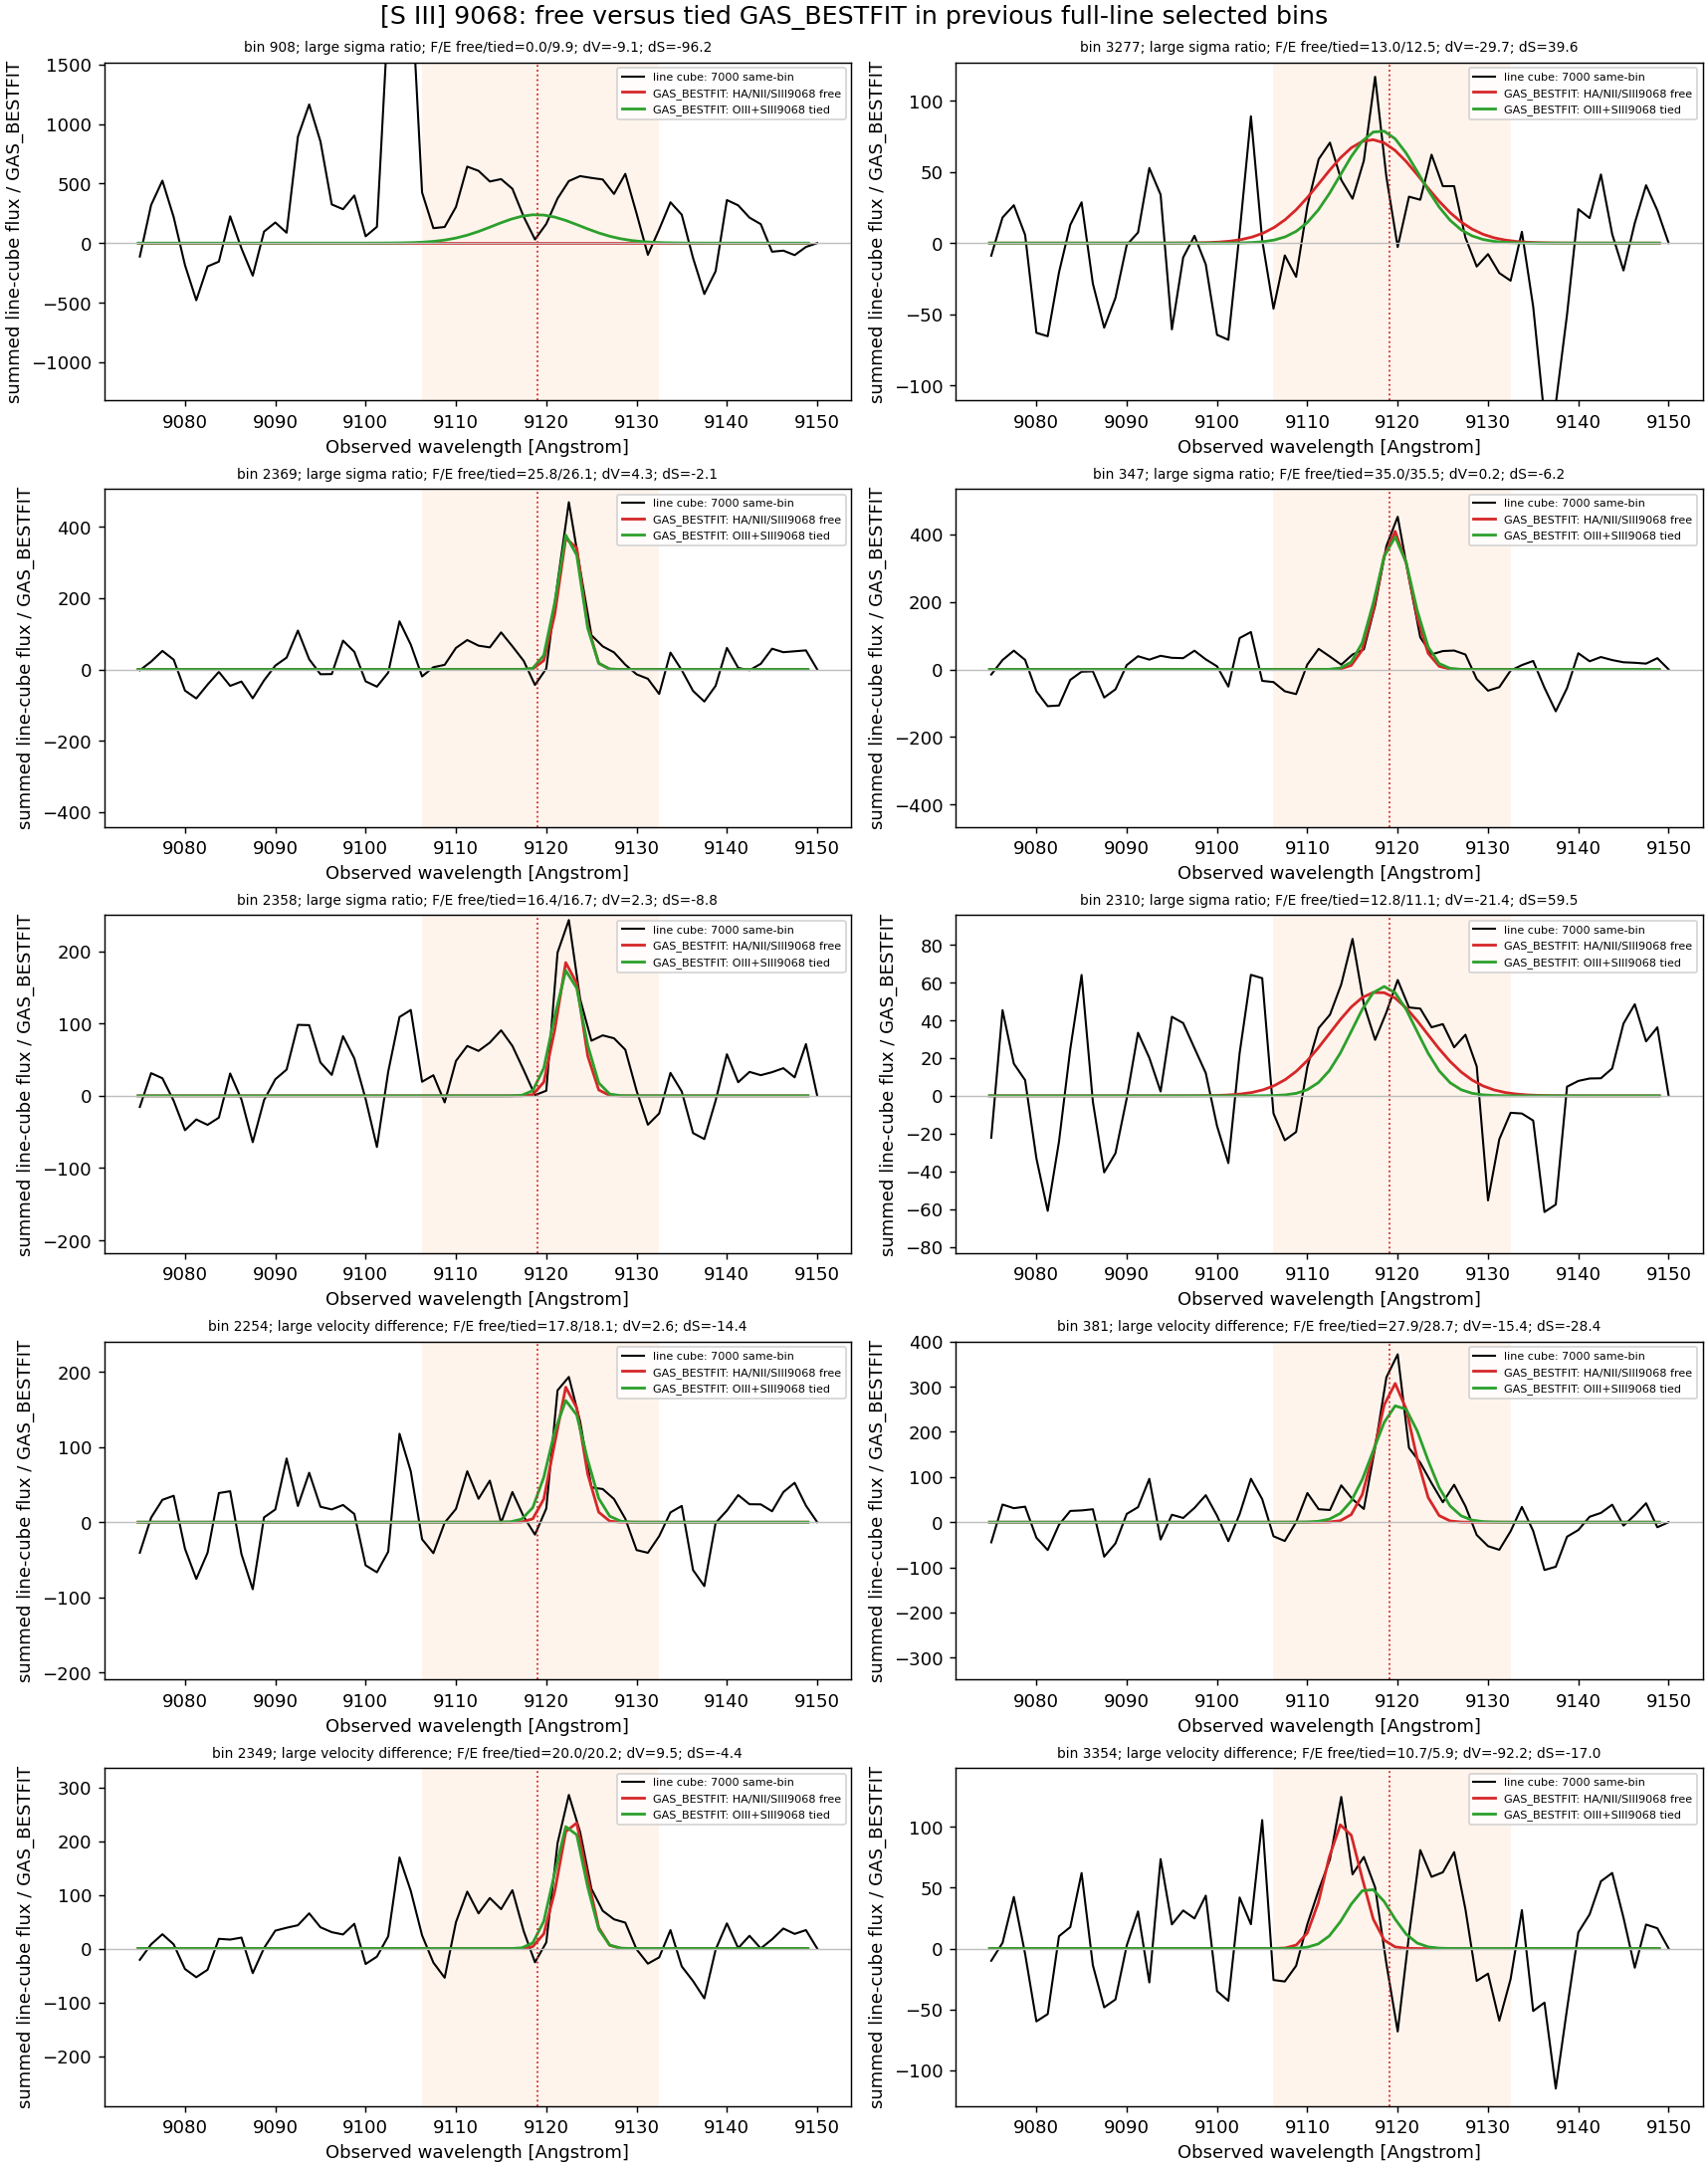

In [8]:
def robust_sigma(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return float(0.5 * (np.nanpercentile(values, 84) - np.nanpercentile(values, 16)))


def sideband_rms(wave, spectrum, center, line_half_width):
    sideband = np.abs(wave - center) > line_half_width
    return robust_sigma(np.asarray(spectrum)[sideband])


def extract_line_cube_slab():
    with fits.open(RUNS[REF_RUN]['line_cube_path'], memmap=True, ignore_missing_end=True) as hdul:
        cube = hdul[0].data
        wave = wavelength_from_header(hdul[0].header, cube.shape[0])
        wave_mask = (wave >= SIII_OBS_A - WAVE_HALF_WIDTH) & (wave <= SIII_OBS_A + WAVE_HALF_WIDTH)
        return wave[wave_mask], np.array(cube[wave_mask, :, :], dtype=float)


def load_bestfit_for_bins(run_key, bin_ids):
    with fits.open(RUNS[run_key]['gas_bestfit_path'], memmap=True, ignore_missing_end=True) as hdul:
        wave = np.exp(np.asarray(hdul['LOGLAM'].data['LOGLAM'], dtype=float)) * (1.0 + REDSHIFT)
        gas_bestfit = hdul['GAS_BESTFIT'].data['GAS_BESTFIT']
        spectra = {}
        for bin_id in bin_ids:
            bin_id = int(bin_id)
            if 0 <= bin_id < len(gas_bestfit):
                spectra[bin_id] = np.array(gas_bestfit[bin_id], dtype=float)
    return wave, spectra

wave_cube, cube_slab = extract_line_cube_slab()
bestfit_cache = {run_key: load_bestfit_for_bins(run_key, SELECTED_BIN_IDS) for run_key in FIT_RUNS}
model_windows = {}
wave_models = {}
line_windows_model = {}
for run_key, (wave_model_full, _) in bestfit_cache.items():
    model_window = (wave_model_full >= SIII_OBS_A - WAVE_HALF_WIDTH) & (wave_model_full <= SIII_OBS_A + WAVE_HALF_WIDTH)
    model_windows[run_key] = model_window
    wave_models[run_key] = wave_model_full[model_window]
    line_windows_model[run_key] = np.abs(wave_models[run_key] - SIII_OBS_A) <= LINE_HALF_WIDTH
line_window_cube = np.abs(wave_cube - SIII_OBS_A) <= LINE_HALF_WIDTH

spectra = []
metric_rows = []
for _, row in selected_bin_table.iterrows():
    bin_id = int(row['bin_id'])
    bin_mask = baseline_bins == bin_id
    linecube = np.nansum(cube_slab[:, bin_mask], axis=1)
    cube_rms = sideband_rms(wave_cube, linecube, SIII_OBS_A, LINE_HALF_WIDTH)
    cube_peak = float(np.nanmax(np.abs(linecube[line_window_cube]))) if np.any(line_window_cube) else np.nan
    models = {}
    metric = {
        'bin_id': bin_id,
        'selection_reason': row['selection_reason'],
        'n_spaxels': row['n_spaxels'],
        'linecube_sideband_rms': cube_rms,
        'linecube_peak_abs': cube_peak,
        'linecube_peak_abs_over_sideband': cube_peak / cube_rms if np.isfinite(cube_rms) and cube_rms > 0 else np.nan,
        'free_fluxerr': row['free_fluxerr'],
        'tied_fluxerr': row['tied_fluxerr'],
        'free_vel': row['free_vel'],
        'tied_vel': row['tied_vel'],
        'free_sigma': row['free_sigma'],
        'tied_sigma': row['tied_sigma'],
        'free_minus_tied_vel': row['free_minus_tied_vel'],
        'free_minus_tied_sigma': row['free_minus_tied_sigma'],
    }
    for run_key in FIT_RUNS:
        wave_model_full, bestfit_by_bin = bestfit_cache[run_key]
        model = bestfit_by_bin.get(bin_id, np.full(wave_model_full.shape, np.nan))[model_windows[run_key]]
        wave_model = wave_models[run_key]
        line_window_model = line_windows_model[run_key]
        interp_linecube = np.interp(wave_model, wave_cube, linecube, left=np.nan, right=np.nan)
        compare_mask = line_window_model & np.isfinite(model) & np.isfinite(interp_linecube)
        model_minus_cube_rms = np.sqrt(np.nanmean((model[compare_mask] - interp_linecube[compare_mask]) ** 2)) if np.count_nonzero(compare_mask) >= 3 else np.nan
        model_peak = float(np.nanmax(np.abs(model[line_window_model]))) if np.any(line_window_model) else np.nan
        prefix = 'free' if run_key == FREE_RUN else 'tied'
        metric[f'{prefix}_model_peak_abs'] = model_peak
        metric[f'{prefix}_model_minus_linecube_rms'] = model_minus_cube_rms
        metric[f'{prefix}_model_minus_linecube_rms_over_sideband'] = model_minus_cube_rms / cube_rms if np.isfinite(model_minus_cube_rms) and np.isfinite(cube_rms) and cube_rms > 0 else np.nan
        models[run_key] = model
    spectra.append({'row': row, 'linecube': linecube, 'models': models})
    metric_rows.append(metric)
fit_metric_table = pd.DataFrame(metric_rows)
display(fit_metric_table)

n = len(spectra)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13.2, 3.35 * nrows), squeeze=False, constrained_layout=True)
fig.suptitle(f'{SIII_LABEL}: free versus tied GAS_BESTFIT in previous full-line selected bins', fontsize=14)

for ax, spec in zip(axes.ravel(), spectra):
    row = spec['row']
    linecube = spec['linecube']
    ax.plot(wave_cube, linecube, color='black', linewidth=1.15, label='line cube: 7000 same-bin')
    for run_key in FIT_RUNS:
        ax.plot(
            wave_models[run_key],
            spec['models'][run_key],
            color=RUNS[run_key]['color'],
            linewidth=1.55,
            label=f'GAS_BESTFIT: {RUNS[run_key]["short_label"]}',
        )
    if np.any(line_window_cube):
        ax.axvspan(wave_cube[line_window_cube].min(), wave_cube[line_window_cube].max(), color='tab:orange', alpha=0.08, linewidth=0)
    ax.axvline(SIII_OBS_A, color='tab:red', linestyle=':', linewidth=1.0)
    ax.axhline(0, color='0.75', linewidth=0.8)

    plotted = [linecube[np.isfinite(linecube)]]
    for model in spec['models'].values():
        plotted.append(model[np.isfinite(model)])
    finite_values = np.concatenate([values for values in plotted if values.size])
    y_scale = np.nanpercentile(np.abs(finite_values), 98) if finite_values.size else 1.0
    y_scale = y_scale if np.isfinite(y_scale) and y_scale > 0 else 1.0
    ax.set_ylim(-1.35 * y_scale, 1.55 * y_scale)
    ax.set_xlabel('Observed wavelength [Angstrom]')
    ax.set_ylabel('summed line-cube flux / GAS_BESTFIT')
    title = (
        f'bin {int(row["bin_id"])}; {row["selection_reason"]}; '
        f'F/E free/tied={row["free_fluxerr"]:.1f}/{row["tied_fluxerr"]:.1f}; '
        f'dV={row["free_minus_tied_vel"]:.1f}; dS={row["free_minus_tied_sigma"]:.1f}'
    )
    ax.set_title(title, fontsize=7.6)
    ax.legend(loc='upper right', fontsize=6.2, frameon=True)

for ax in axes.ravel()[len(spectra):]:
    ax.axis('off')
plt.show()


## Optional Save

Uncomment these lines if CSV output is useful for notes.


In [9]:
# selected_bin_table.to_csv('IC3392_SIII9068_free_vs_tied_previous_bins_map_values_20260515.csv', index=False)
# coverage_table.to_csv('IC3392_SIII9068_free_vs_tied_wavelength_coverage_20260515.csv', index=False)
# pair_bin_table.to_csv('IC3392_SIII9068_free_vs_tied_pairwise_20260515.csv', index=False)
# fit_metric_table.to_csv('IC3392_SIII9068_free_vs_tied_previous_bins_fit_metrics_20260515.csv', index=False)
